In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
areas = ['Eixample', 'Ciutat Vella', 'Gràcia', 'Sarrià-Sant Gervasi']

pivot = pd.pivot_table(
    bcn.query("area in @areas"),
    index="accommodates",
    columns="area",
    values="price_person",
    aggfunc="median"
)

pivot

area,Ciutat Vella,Eixample,Gràcia,Sarrià-Sant Gervasi
accommodates,,,,
2,38.00,81.000000,61.250000,66.250000
3,30.00,63.666667,60.166667,43.666667
4,32.75,59.000000,47.625000,43.500000
5,38.80,53.200000,41.000000,36.800000
6,50.25,50.000000,40.666667,45.833333


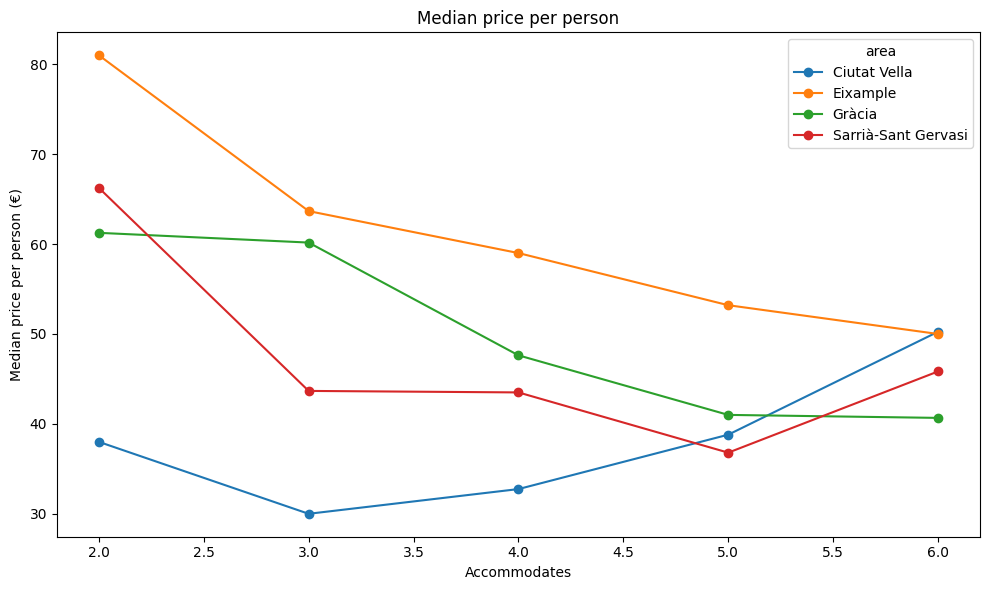

Gráfico guardado en ../reports/graph3.png


In [16]:
ax = pivot.plot(kind="line", marker="o", figsize=(10,6))
ax.set_title("Median price per person")
ax.set_xlabel("Accommodates")
ax.set_ylabel("Median price per person (€)")

plt.tight_layout()
plt.savefig("../reports/graph3.png")
plt.show()

print("Gráfico guardado en ../reports/graph3.png")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

bcn = pd.read_csv("../data/bcn_listings.csv")
mad = pd.read_csv("../data/madrid_listings.csv")

In [5]:
def clean_price(s):
    """Pasa la columna price de string tipo '$120,00' a float."""
    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return s.astype(float)

bcn["price"] = clean_price(bcn["price"])
mad["price"] = clean_price(mad["price"])

In [6]:
# Limpieza adicional en el dataset de Madrid
mad["minimum_nights"] = pd.to_numeric(mad["minimum_nights"], errors="coerce")
# nos quedamos con estancias de hasta 60 noches
mad = mad[mad["minimum_nights"] <= 60]

In [7]:
# Subconjunto Barcelona: pisos enteros 2–6 personas en barrios seleccionados
areas_bcn = ["Eixample", "Ciutat Vella", "Gràcia", "Sarrià-Sant Gervasi"]

bcn_query = (
    "room_type == 'Entire home/apt' "
    "& 1 < accommodates < 7 "
    "& neighbourhood_group_cleansed in @areas_bcn"
)

bcn["price_person"] = bcn["price"] / bcn["accommodates"]

In [8]:
areas_mad = ["Centro", "Salamanca", "Chamberí", "Retiro"]

mad_query = (
    "room_type == 'Entire home/apt' "
    "& 1 < accommodates < 7 "
    "& neighbourhood_group_cleansed in @areas_mad"
)

mad["price_person"] = mad["price"] / mad["accommodates"]

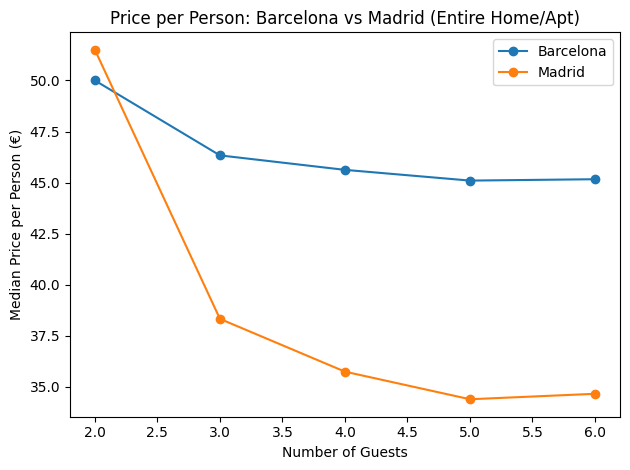

In [12]:
# Median price per person by number of guests
bcn_summary = (
    bcn.query(bcn_query)
    .groupby("accommodates")["price_person"]
    .median()
    .reset_index(name="bcn_price_person")
)

mad_summary = (
    mad.query(mad_query)
    .groupby("accommodates")["price_person"]
    .median()
    .reset_index(name="mad_price_person")
)

summary = bcn_summary.merge(mad_summary, on="accommodates", how="inner")

ax = summary.plot(
    x="accommodates",
    y=["bcn_price_person", "mad_price_person"],
    marker="o",
)

ax.set_xlabel("Number of Guests")
ax.set_ylabel("Median Price per Person (€)")
ax.set_title("Price per Person: Barcelona vs Madrid (Entire Home/Apt)")
ax.legend(["Barcelona", "Madrid"])

plt.tight_layout()
plt.savefig("../reports/graph3.png")
plt.show()

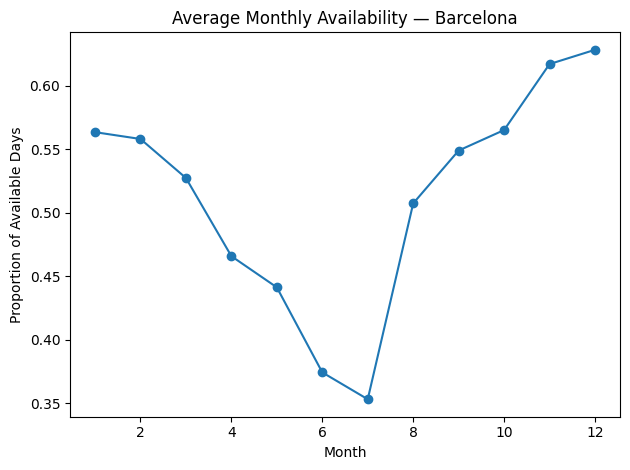

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Barcelona calendar
cal_bcn = pd.read_csv("../data/bcn_calendar.csv")

# Convert date column
cal_bcn["date"] = pd.to_datetime(cal_bcn["date"])

# Extract month number
cal_bcn["month"] = cal_bcn["date"].dt.month

# Compute monthly mean availability (t = available)
monthly_availability_bcn = (
    cal_bcn.groupby("month")["available"]
    .apply(lambda s: (s == "t").mean())
)

# Plot
monthly_availability_bcn.plot(kind="line", marker="o")

plt.title("Average Monthly Availability — Barcelona")
plt.xlabel("Month")
plt.ylabel("Proportion of Available Days")
plt.tight_layout()
plt.savefig("../reports/calendar_bcn.png")
plt.show()

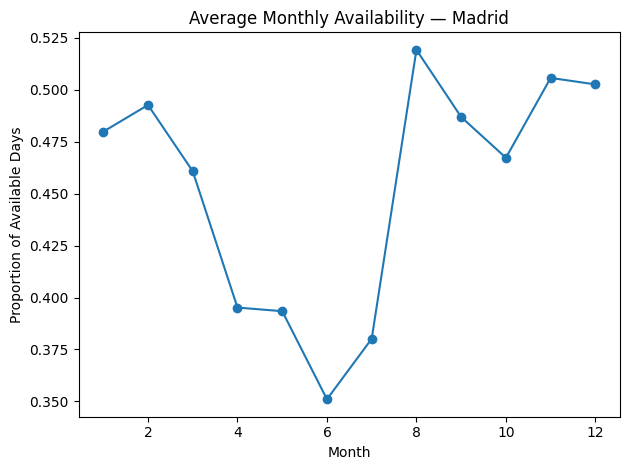

In [10]:
# Load Madrid calendar
cal_mad = pd.read_csv("../data/madrid_calendar.csv")

# Convert date column
cal_mad["date"] = pd.to_datetime(cal_mad["date"])

# Extract month number
cal_mad["month"] = cal_mad["date"].dt.month

# Compute monthly mean availability
monthly_availability_mad = (
    cal_mad.groupby("month")["available"]
    .apply(lambda s: (s == "t").mean())
)

# Plot
monthly_availability_mad.plot(kind="line", marker="o")

plt.title("Average Monthly Availability — Madrid")
plt.xlabel("Month")
plt.ylabel("Proportion of Available Days")
plt.tight_layout()
plt.savefig("../reports/calendar_madrid.png")
plt.show()

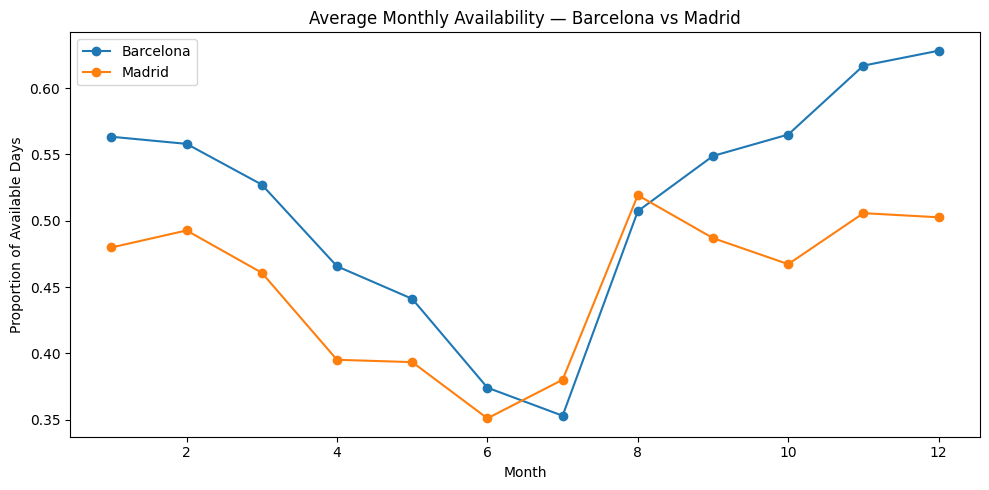

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load and process Barcelona calendar ---
cal_bcn = pd.read_csv("../data/bcn_calendar.csv")
cal_bcn["date"] = pd.to_datetime(cal_bcn["date"])
cal_bcn["month"] = cal_bcn["date"].dt.month

monthly_availability_bcn = (
    cal_bcn.groupby("month")["available"]
    .apply(lambda s: (s == "t").mean())
)

# --- Load and process Madrid calendar ---
cal_mad = pd.read_csv("../data/madrid_calendar.csv")
cal_mad["date"] = pd.to_datetime(cal_mad["date"])
cal_mad["month"] = cal_mad["date"].dt.month

monthly_availability_mad = (
    cal_mad.groupby("month")["available"]
    .apply(lambda s: (s == "t").mean())
)

# --- Plot comparison ---
plt.figure(figsize=(10, 5))
plt.plot(monthly_availability_bcn.index, monthly_availability_bcn.values, marker="o", label="Barcelona")
plt.plot(monthly_availability_mad.index, monthly_availability_mad.values, marker="o", label="Madrid")

plt.title("Average Monthly Availability — Barcelona vs Madrid")
plt.xlabel("Month")
plt.ylabel("Proportion of Available Days")
plt.legend()
plt.tight_layout()

plt.savefig("../reports/calendar_comparison.png")
plt.show()